## Notebook for preprocessing and formatting the Norman data

In [1]:
# set up environment
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
# control panel
data_folder    = '../../../data/real/Norman2019/'
output_folder  = '../../../data/real/Norman2019/'
tf_info_file   = data_folder + 'GRN/' + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet"

# parameters from notebook 2 — must match what was used there
top_percentage = 0.4    # fraction of top-ranked GRN edges retained
best_key       = 1.1 # 0.9 1.0 1.4 2.5   # best gamma_reg selected by stability analysis

# derived name components (mirrors notebook 2 convention)
_top_pct = int(top_percentage * 100)
_gamma   = str(best_key).replace('.', 'p')

unprocessed_data_file = data_folder + 'Norman2019_raw.h5ad'
grn_genes_file        = data_folder + 'GRN/' + f'all_genes_{_top_pct}pct.txt'
tf_communities_file   = data_folder + 'GRN/' + f'tf_communities_{_top_pct}pct_gamma{_gamma}.csv'
processed_data_file   = output_folder + f'Norman2019_processed_{_top_pct}pct_gamma{_gamma}.h5ad'
pseudobulk_data_file  = output_folder + f'Norman2019_pseudobulk_{_top_pct}pct_gamma{_gamma}.h5ad'

In [3]:
# load data
adata = sc.read_h5ad(unprocessed_data_file)
tf_info = pd.read_parquet(tf_info_file)
grn_genes = pd.read_csv(grn_genes_file, header=None)[0].tolist()


### Preprocessing single cell data
Not strictly needed, just making sure we are using normalized, log transformed data

In [4]:
# Set .X to raw counts from the 'counts' layer
adata.X = adata.layers['counts'].copy()
adata.layers['counts'] = adata.X.copy()  # optional: preserve a copy

# Normalize total
sc.pp.normalize_total(adata)

# Log1p
sc.pp.log1p(adata)


## Restricting to genes in the GRN

In [5]:
# selecting only genes in the GRN
adata = adata[:, adata.var.gene_symbols.isin(grn_genes)].copy()

### Formatting the adata.var data frame

In [6]:
# setting var index to gene_symbols
adata.var.loc[:, 'ensembl'] = adata.var.index.copy()
adata.var.set_index('gene_symbols', inplace=True)

# setting the "kind" column to indicate TFs and non-TFs
adata.var['kind'] = 'TG'
tf_names = set(tf_info.columns.unique())
adata.var.loc[adata.var.index.isin(tf_names), 'kind'] = 'TF'

# adding the community information to adata.var
tmp = pd.read_csv(tf_communities_file)
tf2latent = dict(zip(tmp["tf"], tmp["community"]))
adata.var['community'] =adata.var.index.map(tf2latent).astype('category')

# printing the adata.var to check
adata.var

,highly_variable,means,dispersions,dispersions_norm,ensembl,kind,community
gene_symbols,,,,,,,
SAMD11,True,0.028155,0.826190,2.014739,ENSG00000187634,TG,NaN
HES4,True,0.301794,0.438797,0.728025,ENSG00000188290,TF,0.0
ISG15,True,0.479069,0.546466,1.125694,ENSG00000187608,TG,NaN
MMP23B,True,0.044102,0.401262,0.603067,ENSG00000189409,TG,NaN
TNFRSF14,True,0.013270,0.492174,0.905088,ENSG00000157873,TG,NaN
...,...,...,...,...,...,...,...
CSTB,True,1.868582,0.607073,0.912440,ENSG00000160213,TG,NaN
ITGB2,True,0.108327,1.150182,3.091084,ENSG00000160255,TF,8.0
ITGB2-AS1,True,0.031423,0.617441,1.321243,ENSG00000227039,TG,NaN


### Formatting the adata.obs data frame

In [7]:
# Note: the cell_type column is alredy present in adata.obs
# adata.obs.cell_type

# adding and formatting the intervention column
adata.obs.loc[: , 'intervention'] = adata.obs['condition'].astype('str')
adata.obs.loc[:, 'intervention'] = adata.obs['intervention'].str.replace('+ctrl', '', regex=False).astype('str')
adata.obs.loc[:, 'intervention'] = adata.obs['intervention'].str.replace('ctrl+', '', regex=False).astype('str')
adata.obs.loc[:, 'intervention'] = adata.obs['intervention'].str.replace('ctrl', 'unperturbed', regex=False).astype('str')
adata.obs

,guide_identity,read_count,UMI_count,gemgroup,good_coverage,number_of_cells,guide_ids,guide_merged,split,batch,condition,cell_type,dose_val,control,drug_dose_name,cov_drug_dose_name,intervention
index,,,,,,,,,,,,,,,,,
TGCGGGTTCTAGAGTC-5-0-0,FOXL2_MEIS1__FOXL2_MEIS1,960,36,5,True,1,"FOXL2,MEIS1",FOXL2+MEIS1,train,0,FOXL2+MEIS1,K562,1+1,0,FOXL2+MEIS1,K562_FOXL2+MEIS1_1+1,FOXL2+MEIS1
TTCCCAGGTTCAACCA-7-0-0,NegCtrl0_PRTG__NegCtrl0_PRTG,2069,109,7,True,1,PRTG,ctrl+PRTG,train,0,ctrl+PRTG,K562,1+1,0,ctrl+PRTG,K562_ctrl+PRTG_1+1,PRTG
ATTGGTGTCTGTCTAT-6-0-0,CNN1_MAPK1__CNN1_MAPK1,1850,95,6,True,1,"CNN1,MAPK1",CNN1+MAPK1,train,0,CNN1+MAPK1,K562,1+1,0,CNN1+MAPK1,K562_CNN1+MAPK1_1+1,CNN1+MAPK1
TGGCTGGAGACAAGCC-3-0-0,DUSP9_PRTG__DUSP9_PRTG,1385,65,3,True,1,"DUSP9,PRTG",DUSP9+PRTG,train,0,DUSP9+PRTG,K562,1+1,0,DUSP9+PRTG,K562_DUSP9+PRTG_1+1,DUSP9+PRTG
CCCAGTTCATCCTTGC-6-0-0,DUSP9_IGDCC3__DUSP9_IGDCC3,493,21,6,True,1,"DUSP9,IGDCC3",DUSP9+IGDCC3,train,0,DUSP9+IGDCC3,K562,1+1,0,DUSP9+IGDCC3,K562_DUSP9+IGDCC3_1+1,DUSP9+IGDCC3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAAGGCCCAGCTTCGG-2-1-1,NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0,2333,137,2,True,1,,ctrl,test,1,ctrl,K562,1,1,ctrl,K562_ctrl_1,unperturbed
GCGCAGTAGGAATCGC-1-1-1,NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0,1924,96,1,True,1,,ctrl,test,1,ctrl,K562,1,1,ctrl,K562_ctrl_1,unperturbed
GGGATGACAGGTGGAT-1-1-1,NegCtrl11_NegCtrl0__NegCtrl11_NegCtrl0,178,11,1,True,1,,ctrl,test,1,ctrl,K562,1,1,ctrl,K562_ctrl_1,unperturbed


### Restrict single and double perturbations to TF that are (a) present in adata.var and (b) in a community

In [8]:
# get list of valid TFs 
idx = (adata.var['kind'] == 'TF') & (adata.var['community'].notna())
tf_list = set(adata.var[idx].index.tolist())

# function to check if all perturbed genes are TFs
def all_genes_are_tfs(intervention, tf_list):
    if intervention == 'unperturbed':
        return True
    # Split by '+' to handle both single and double perturbations
    genes = intervention.split('+')
    return all(gene in tf_list for gene in genes)

# apply filter
mask = adata.obs['intervention'].apply(lambda x: all_genes_are_tfs(x, tf_list))
adata = adata[mask, :].copy()

# print summary
print(f"Filtered cells: {adata.n_obs}")
print(f"Unique interventions retained: {adata.obs['intervention'].nunique()}")
print(adata.obs['intervention'].unique())

 # print adata for checking
adata

Filtered cells: 35392
Unique interventions retained: 61
['FOXL2+MEIS1' 'CEBPB' 'SPI1' 'FOXA1+HOXB9' 'DLX2' 'AHR+FEV' 'MEIS1'
 'AHR+KLF1' 'CEBPE+KLF1' 'FOXA3+FOXF1' 'IRF1' 'OSR2' 'LYL1+CEBPB' 'KLF1'
 'LHX1' 'CEBPE' 'TBX3' 'FOSB+CEBPE' 'HNF4A' 'FOXA3' 'JUN+CEBPA'
 'TBX3+TBX2' 'AHR' 'FOXF1+HOXB9' 'ETS2' 'CEBPA' 'FOXF1' 'HOXA13'
 'KLF1+CEBPA' 'LYL1' 'HOXB9' 'FOXL2' 'FOXA3+HOXB9' 'PRDM1' 'FOXA1+FOXL2'
 'EGR1' 'FOXA1+FOXF1' 'CEBPB+OSR2' 'JUN' 'FOSB' 'KLF1+FOXA1' 'CEBPB+CEBPA'
 'FOXA1' 'CEBPE+CEBPB' 'CEBPE+SPI1' 'FOXA3+FOXL2' 'ETS2+CEBPE' 'FEV'
 'CEBPE+CEBPA' 'HOXC13' 'TBX2' 'JUN+CEBPB' 'FOSB+OSR2' 'HES7' 'POU3F2'
 'POU3F2+FOXL2' 'FOSB+CEBPB' 'FOXF1+FOXL2' 'FOXA3+FOXA1' 'FOXL2+HOXB9'
 'unperturbed']


AnnData object with n_obs × n_vars = 35392 × 1642
    obs: 'guide_identity', 'read_count', 'UMI_count', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_ids', 'guide_merged', 'split', 'batch', 'condition', 'cell_type', 'dose_val', 'control', 'drug_dose_name', 'cov_drug_dose_name', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensembl', 'kind', 'community'
    uns: 'rank_genes_groups', 'rank_genes_groups_cov', 'log1p'
    layers: 'counts'

In [9]:
# keeping only interventions with more than 100 cells

# quantifying the number of cells for each intervention 
int_cell_count = adata.obs['intervention'].value_counts() 

# which intervention to retain?
to_retain = int_cell_count[int_cell_count > 100].index.to_list()

# selection
adata = adata[adata.obs['intervention'].isin(to_retain)].copy()
adata

AnnData object with n_obs × n_vars = 35048 × 1642
    obs: 'guide_identity', 'read_count', 'UMI_count', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_ids', 'guide_merged', 'split', 'batch', 'condition', 'cell_type', 'dose_val', 'control', 'drug_dose_name', 'cov_drug_dose_name', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensembl', 'kind', 'community'
    uns: 'rank_genes_groups', 'rank_genes_groups_cov', 'log1p'
    layers: 'counts'

In [10]:
# checking communities
adata.var['community'].value_counts()

community
1.0    30
0.0    28
2.0    23
4.0    18
3.0    17
5.0    12
8.0    11
6.0     2
Name: count, dtype: int64

In [11]:
# Compute pseudobulks by averaging gene expression per intervention
pseudobulk_list = []
intervention_labels = []

for intervention in adata.obs['intervention'].unique():
    # Get cells for this intervention
    mask = adata.obs['intervention'] == intervention
    cells_subset = adata[mask, :]
    
    # Compute mean expression across cells
    mean_expr = cells_subset.X.mean(axis=0)
    if hasattr(mean_expr, 'A1'):  # Convert sparse matrix to array if needed
        mean_expr = mean_expr.A1
    
    pseudobulk_list.append(mean_expr)
    intervention_labels.append(intervention)

# Create pseudobulk matrix
pseudobulk_matrix = np.vstack(pseudobulk_list)

# Create AnnData object for pseudobulks
adata_pseudobulk = sc.AnnData(
    X=pseudobulk_matrix,
    obs=pd.DataFrame({'intervention': intervention_labels}),
    var=adata.var.copy()
)

print(f"Pseudobulk data shape: {adata_pseudobulk.shape}")
print(f"Number of interventions: {len(intervention_labels)}")
adata_pseudobulk

# saving
adata_pseudobulk.write_h5ad(pseudobulk_data_file)


Pseudobulk data shape: (56, 1642)
Number of interventions: 56


/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [12]:
# Compute distances between each intervention and unperturbed cells in pseudobulk space
# Using MSE (Mean Squared Error) as in train_gcrl_vae.py centroid loss

# Get unperturbed pseudobulk
unperturbed_mask = adata_pseudobulk.obs['intervention'] == 'unperturbed'
unperturbed_pseudobulk = adata_pseudobulk.X[unperturbed_mask]

if len(unperturbed_pseudobulk) == 0:
    print("Warning: No unperturbed cells found in pseudobulk data")
else:
    # Should have exactly one unperturbed pseudobulk
    unperturbed_centroid = unperturbed_pseudobulk[0]  # (n_genes,)
    
    # Compute MSE distance for each intervention
    distances = []
    intervention_names = []
    
    for i, intervention in enumerate(adata_pseudobulk.obs['intervention']):
        intervention_centroid = adata_pseudobulk.X[i]  # (n_genes,)
        
        # MSE distance (same as in train_gcrl_vae.py line 1442)
        mse_distance = np.mean((intervention_centroid - unperturbed_centroid) ** 2)
        
        distances.append(mse_distance)
        intervention_names.append(intervention)
    
    # Create DataFrame with results
    distance_df = pd.DataFrame({
        'intervention': intervention_names,
        'mse_distance_to_unperturbed': distances
    })
    
    # Sort by distance (ascending)
    distance_df = distance_df.sort_values('mse_distance_to_unperturbed', ascending=True)
    
    print("\nDistances from unperturbed (sorted by distance):")
    print("=" * 60)
    print(distance_df.to_string(index=False))
    print("=" * 60)
    print(f"\nMean distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].mean():.6f}")
    print(f"Std distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].std():.6f}")
    print(f"Min distance (excluding unperturbed): {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].min():.6f}")
    print(f"Max distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].max():.6f}")



Distances from unperturbed (sorted by distance):
intervention  mse_distance_to_unperturbed
 unperturbed                     0.000000
       FOXF1                     0.001243
       MEIS1                     0.001642
        LYL1                     0.002494
       FOXA1                     0.003223
        EGR1                     0.003573
      POU3F2                     0.004602
        FOSB                     0.004855
       FOXA3                     0.004888
        DLX2                     0.005063
       HOXB9                     0.005118
         AHR                     0.005495
       FOXL2                     0.005656
        ETS2                     0.006079
  CEBPE+KLF1                     0.006678
        LHX1                     0.007333
        OSR2                     0.008248
        KLF1                     0.008287
        TBX2                     0.008296
         JUN                     0.008454
    AHR+KLF1                     0.010442
  KLF1+FOXA1              

In [13]:
# Focus on double perturbations and split into train/test based on distance ranking
# Double perturbations have "+" in their name (e.g., "FOXA1+HOXB9")
# All single perturbations and unperturbed cells go to training set

# Filter for double perturbations only
double_perturb_df = distance_df[distance_df['intervention'].str.contains(r'\+', regex=True)].copy()

# Sort by distance (already sorted from previous cell, but let's be explicit)
double_perturb_df = double_perturb_df.sort_values('mse_distance_to_unperturbed', ascending=True).reset_index(drop=True)

print("Double perturbations ranked by distance from unperturbed:")
print("=" * 70)
for idx, row in double_perturb_df.iterrows():
    print(f"{idx+1:2d}. {row['intervention']:20s} - Distance: {row['mse_distance_to_unperturbed']:.6f}")
print("=" * 70)

# Select every second double perturbation for test set (indices 1, 3, 5, ...)
# The rest go to training set (indices 0, 2, 4, ...)
test_interventions = double_perturb_df.iloc[1::2]['intervention'].tolist()
train_interventions = double_perturb_df.iloc[0::2]['intervention'].tolist()

print(f"\n📊 Split Summary:")
print(f"   Total double perturbations: {len(double_perturb_df)}")
print(f"   Training set: {len(train_interventions)} double perturbations")
print(f"   Test set: {len(test_interventions)} double perturbations")

print(f"\n✅ Training set double perturbations:")
for i, interv in enumerate(train_interventions, 1):
    dist = double_perturb_df[double_perturb_df['intervention'] == interv]['mse_distance_to_unperturbed'].values[0]
    print(f"   {i:2d}. {interv:20s} - Distance: {dist:.6f}")

print(f"\n🧪 Test set double perturbations:")
for i, interv in enumerate(test_interventions, 1):
    dist = double_perturb_df[double_perturb_df['intervention'] == interv]['mse_distance_to_unperturbed'].values[0]
    print(f"   {i:2d}. {interv:20s} - Distance: {dist:.6f}")

# Now update the 'set' column in adata.obs
# First, check if 'set' column exists, if not create it
if 'set' not in adata.obs.columns:
    # Initialize all as 'training' by default
    adata.obs['set'] = 'training'
    print("\n⚠️  'set' column created and initialized to 'training' for all cells")
else:
    print(f"\n✓ 'set' column already exists")

# IMPORTANT: Set ALL cells to 'training' first (including single perturbations and unperturbed)
adata.obs['set'] = 'training'
print(f"\n🔄 Reset all cells to 'training' (ensures single perturbations and unperturbed are in training)")

# Then update ONLY the test set double perturbations
print(f"\n📝 Assigning double perturbations to train/test sets:")
for interv in test_interventions:
    mask = adata.obs['intervention'] == interv
    adata.obs.loc[mask, 'set'] = 'test'
    print(f"   ✓ Set {mask.sum()} cells with intervention '{interv}' to TEST")

# Verify training set (should already be set, but let's be explicit for logging)
for interv in train_interventions:
    mask = adata.obs['intervention'] == interv
    n_cells = mask.sum()
    print(f"   ✓ {n_cells} cells with intervention '{interv}' in TRAINING")

# Summary of final split
print(f"\n📈 Final Dataset Split:")
print(f"   Training cells: {(adata.obs['set'] == 'training').sum():,}")
print(f"   Test cells: {(adata.obs['set'] == 'test').sum():,}")
print(f"   Total cells: {adata.n_obs:,}")

# Show detailed breakdown by intervention type
print(f"\n📋 Detailed Breakdown:")
double_train_mask = adata.obs['intervention'].str.contains(r'\+', regex=True) & (adata.obs['set'] == 'training')
double_test_mask = adata.obs['intervention'].str.contains(r'\+', regex=True) & (adata.obs['set'] == 'test')
single_mask = ~adata.obs['intervention'].str.contains(r'\+', regex=True) & (adata.obs['intervention'] != 'unperturbed')
unperturbed_mask = adata.obs['intervention'] == 'unperturbed'

print(f"   Training set:")
print(f"      - Double perturbations: {adata.obs[double_train_mask]['intervention'].nunique()} interventions, {double_train_mask.sum():,} cells")
print(f"      - Single perturbations: {adata.obs[single_mask]['intervention'].nunique()} interventions, {single_mask.sum():,} cells")
print(f"      - Unperturbed: {unperturbed_mask.sum():,} cells")
print(f"   Test set:")
print(f"      - Double perturbations: {adata.obs[double_test_mask]['intervention'].nunique()} interventions, {double_test_mask.sum():,} cells")
print(f"      - Single perturbations: 0 interventions, 0 cells (all in training)")
print(f"      - Unperturbed: 0 cells (all in training)")

# Verify no single perturbations or unperturbed in test set
test_singles = adata.obs[(adata.obs['set'] == 'test') & single_mask]
test_unperturbed = adata.obs[(adata.obs['set'] == 'test') & unperturbed_mask]
if len(test_singles) > 0 or len(test_unperturbed) > 0:
    print(f"\n⚠️  WARNING: Found single perturbations or unperturbed in test set!")
else:
    print(f"\n✅ Verified: Only double perturbations in test set, all single perturbations and unperturbed in training set")


Double perturbations ranked by distance from unperturbed:
 1. CEBPE+KLF1           - Distance: 0.006678
 2. AHR+KLF1             - Distance: 0.010442
 3. KLF1+FOXA1           - Distance: 0.010563
 4. FOXA3+FOXF1          - Distance: 0.010802
 5. FOXA1+FOXF1          - Distance: 0.011099
 6. LYL1+CEBPB           - Distance: 0.011164
 7. FOXL2+MEIS1          - Distance: 0.012502
 8. FOXA1+FOXL2          - Distance: 0.013340
 9. FOXF1+HOXB9          - Distance: 0.013583
10. TBX3+TBX2            - Distance: 0.015145
11. FOXA3+FOXA1          - Distance: 0.016102
12. FOXA1+HOXB9          - Distance: 0.017472
13. FOXF1+FOXL2          - Distance: 0.018450
14. POU3F2+FOXL2         - Distance: 0.018910
15. ETS2+CEBPE           - Distance: 0.020598
16. FOXA3+HOXB9          - Distance: 0.021041
17. FOSB+OSR2            - Distance: 0.022581
18. FOXA3+FOXL2          - Distance: 0.022875
19. CEBPB+OSR2           - Distance: 0.027900
20. AHR+FEV              - Distance: 0.030081
21. CEBPE+CEBPB       

In [14]:
# CORRECTION: ALL DOUBLE PERTURBATIONS GO TO TEST, ALL SINGLE PERTURBATIONS AND UNPERTURBED GO TO TRAINING

is_test = adata.obs['intervention'].str.contains(r'\+', regex=True)  # double perturbations
adata.obs['set'] = np.where(is_test, 'test', 'training')

# Show detailed breakdown by intervention type
print(f"\n📋 Detailed Breakdown:")
double_train_mask = adata.obs['intervention'].str.contains(r'\+', regex=True) & (adata.obs['set'] == 'training')
double_test_mask = adata.obs['intervention'].str.contains(r'\+', regex=True) & (adata.obs['set'] == 'test')
single_mask = ~adata.obs['intervention'].str.contains(r'\+', regex=True) & (adata.obs['intervention'] != 'unperturbed')
unperturbed_mask = adata.obs['intervention'] == 'unperturbed'

print(f"   Training set:")
print(f"      - Double perturbations: {adata.obs[double_train_mask]['intervention'].nunique()} interventions, {double_train_mask.sum():,} cells")
print(f"      - Single perturbations: {adata.obs[single_mask]['intervention'].nunique()} interventions, {single_mask.sum():,} cells")
print(f"      - Unperturbed: {unperturbed_mask.sum():,} cells")
print(f"   Test set:")
print(f"      - Double perturbations: {adata.obs[double_test_mask]['intervention'].nunique()} interventions, {double_test_mask.sum():,} cells")
print(f"      - Single perturbations: 0 interventions, 0 cells (all in training)")
print(f"      - Unperturbed: 0 cells (all in training)")

# Verify no single perturbations or unperturbed in test set
test_singles = adata.obs[(adata.obs['set'] == 'test') & single_mask]
test_unperturbed = adata.obs[(adata.obs['set'] == 'test') & unperturbed_mask]
if len(test_singles) > 0 or len(test_unperturbed) > 0:
    print(f"\n⚠️  WARNING: Found single perturbations or unperturbed in test set!")
else:
    print(f"\n✅ Verified: Only double perturbations in test set, all single perturbations and unperturbed in training set")



📋 Detailed Breakdown:
   Training set:
      - Double perturbations: 0 interventions, 0 cells
      - Single perturbations: 30 interventions, 18,811 cells
      - Unperturbed: 8,907 cells
   Test set:
      - Double perturbations: 25 interventions, 7,330 cells
      - Single perturbations: 0 interventions, 0 cells (all in training)
      - Unperturbed: 0 cells (all in training)

✅ Verified: Only double perturbations in test set, all single perturbations and unperturbed in training set


### Visualization

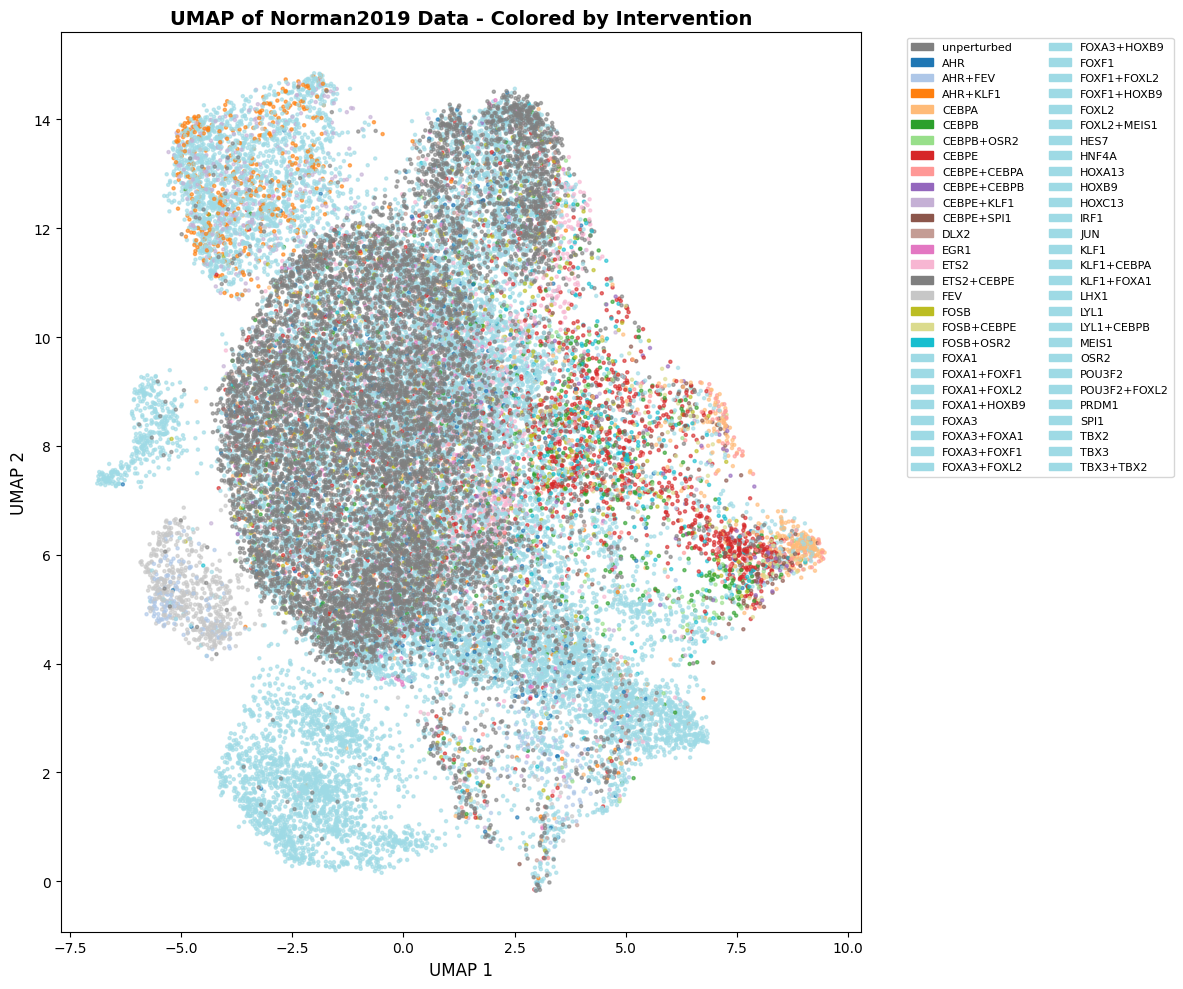

In [15]:
# Compute PCA (required for UMAP)
sc.tl.pca(adata)

# Compute UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

# Create color mapping: unperturbed in grey, others in distinct colors
interventions = adata.obs['intervention'].unique()
n_interventions = len(interventions)

# Generate color palette
color_palette = plt.cm.tab20(range(n_interventions))

# Create color map dictionary
intervention_colors = {}
for i, intervention in enumerate(sorted(interventions)):
    if intervention == 'unperturbed':
        intervention_colors[intervention] = '#808080'  # grey
    else:
        intervention_colors[intervention] = color_palette[i]

# Map colors to cells
cell_colors = [intervention_colors[intervention] for intervention in adata.obs['intervention']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP
scatter = ax.scatter(
    adata.obsm['X_umap'][:, 0],
    adata.obsm['X_umap'][:, 1],
    c=cell_colors,
    s=5,
    alpha=0.6
)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Norman2019 Data - Colored by Intervention', fontsize=14, fontweight='bold')

# Create legend (only show subset to avoid overcrowding)
legend_elements = []
for intervention in sorted(interventions):
    if intervention == 'unperturbed':
        legend_elements.insert(0, mpatches.Patch(color=intervention_colors[intervention], label=intervention))
    else:
        legend_elements.append(mpatches.Patch(color=intervention_colors[intervention], label=intervention))

# Add legend with smaller font and multiple columns
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left',
          fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

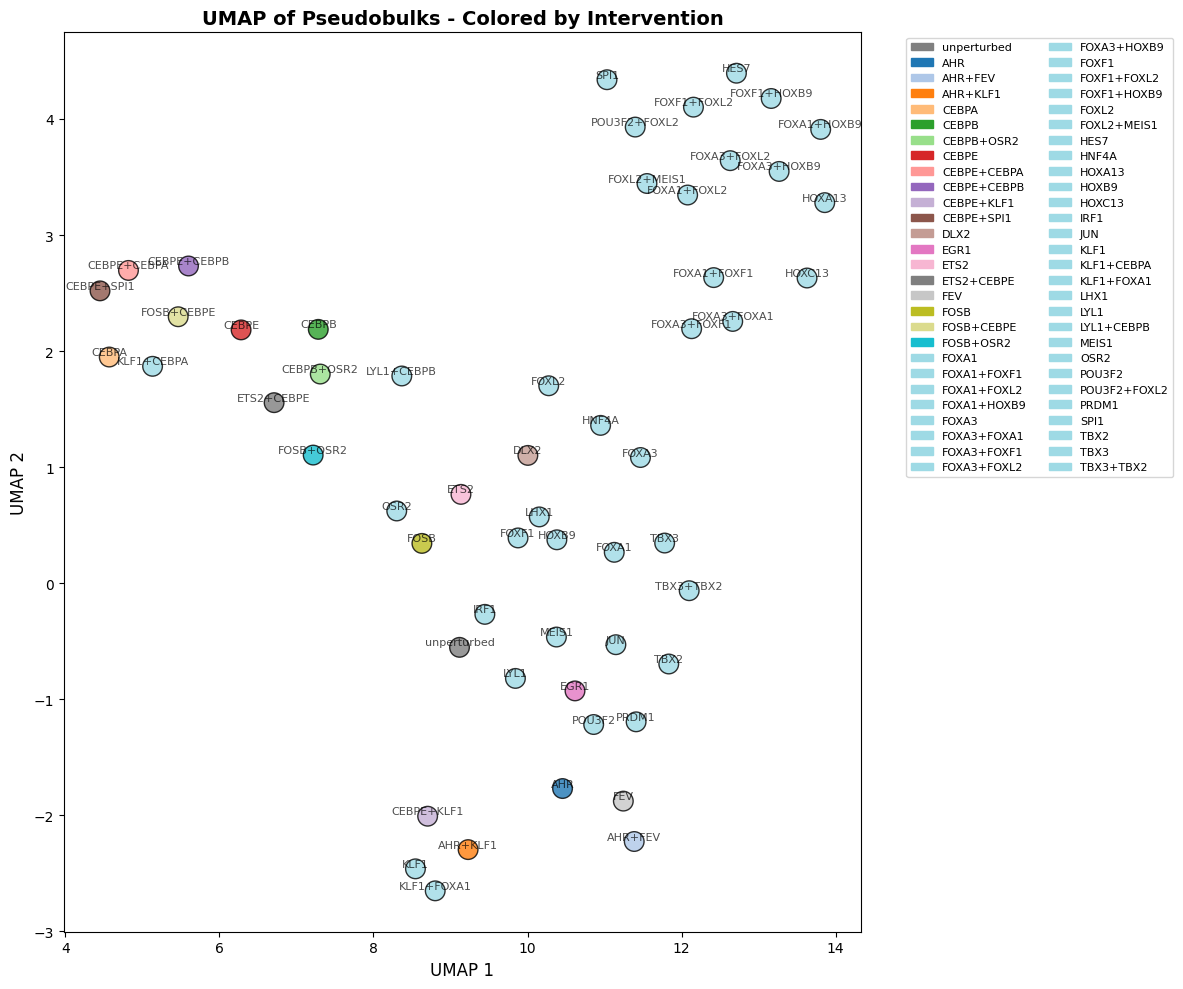

In [16]:
# Compute PCA for pseudobulks
sc.tl.pca(adata_pseudobulk)

# Compute UMAP for pseudobulks
sc.pp.neighbors(adata_pseudobulk, n_neighbors=5, n_pcs=20)
sc.tl.umap(adata_pseudobulk)

# Use same color scheme as before
pseudobulk_colors = [intervention_colors[intervention] for intervention in adata_pseudobulk.obs['intervention']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP
scatter = ax.scatter(
    adata_pseudobulk.obsm['X_umap'][:, 0],
    adata_pseudobulk.obsm['X_umap'][:, 1],
    c=pseudobulk_colors,
    s=200,
    alpha=0.8,
    edgecolors='black',
    linewidth=1
)

# Add labels for each point
for i, intervention in enumerate(adata_pseudobulk.obs['intervention']):
    ax.annotate(
        intervention,
        (adata_pseudobulk.obsm['X_umap'][i, 0], adata_pseudobulk.obsm['X_umap'][i, 1]),
        fontsize=8,
        ha='center',
        va='bottom',
        alpha=0.7
    )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Pseudobulks - Colored by Intervention', fontsize=14, fontweight='bold')

# Add legend
legend_elements = []
for intervention in sorted(adata_pseudobulk.obs['intervention'].unique()):
    if intervention == 'unperturbed':
        legend_elements.insert(0, mpatches.Patch(color=intervention_colors[intervention], label=intervention))
    else:
        legend_elements.append(mpatches.Patch(color=intervention_colors[intervention], label=intervention))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
          fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

### Saving

In [17]:
# saving to output file
adata.write_h5ad(processed_data_file)
print(f'Saved processed data → {processed_data_file}')

Saved processed data → ../../../data/real/Norman2019/Norman2019_processed_40pct_gamma1p1.h5ad
